### Context engineering in Deep Agents
Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably.
Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [20]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [21]:
from langchain.chat_models import init_chat_model

model=init_chat_model("groq:openai/gpt-oss-safeguard-20b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Safety GPT OSS 20B', 'release_date': '2025-03-05', 'last_updated': '2025-03-05', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000170046FAE90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000170046FB890>, model_name='openai/gpt-oss-safeguard-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

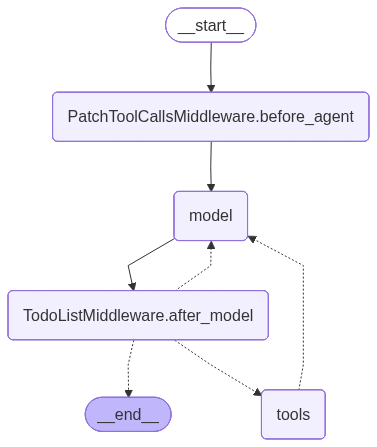

In [22]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model=model,
    system_prompt=(
        "You are a research assistant specializing in scientific literature. "
        "Always cite sources. Use subagents for parallel research on different topics."

    ),
)
agent

In [23]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='51ec7e3b-9980-4273-a598-87f617fcb767'),
  AIMessage(content='DeepAgent is a specialized AI assistant designed to help users complete complex, multi‑step tasks by orchestrating internal sub‑agents and external tools. It can spawn “subagents” (e.g., general‑purpose, research‑analyst) to isolate and execute independent tasks, manage a structured to‑do list for long‑running projects, and interact with filesystem tools (ls, read_file, write_file, etc.) to read, edit, and search code or data. The goal is to keep the main thread lightweight while delegating heavy, context‑intensive work to dedicated workers, ensuring accurate, well‑structured outputs.', additional_kwargs={'reasoning_content': 'User asks "What is deepagent?" Likely referring to this agent? But maybe they mean deep agent? The context: we are a deep agent. So explain what deepagent is: a specialized AI that helps users accomp

## Context Engineering with `AGENTS.md`

Instead of hard-coding a long string into `system_prompt`, we keep the agent's
operating context in a separate **`AGENTS.md`** file. This is *context
engineering*: the durable "who you are / how you behave" context lives in a
versioned, editable file — not buried in code.

#### AGENTS.md is a file you can save it in projects folder. It's a file used for our testing.

In [24]:
from pathlib import Path
agents_md=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md


'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [25]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer=MemorySaver()

## Backends: where the agent's files / memory live

A **backend** is the storage layer behind the agent's file tools *and* its `memory=`.
Same agent code, different durability:

| Backend | Lives in | Survives across | Use it when… |
|---------|----------|-----------------|--------------|
| **StateBackend** (default) | LangGraph state (the `files` channel) | one thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| **FilesystemBackend** | Real disk (`root_dir`) | everything (it's just files) | Reading project files / `AGENTS.md` that already exist on disk. |
| **StoreBackend** | LangGraph `BaseStore` | **all threads** (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. |

In [10]:
agent = create_deep_agent(
    model=model,
    checkpointer=MemorySaver(),
    # no backend, no memory=, no files=
)
result = agent.invoke(
    {
       "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I am a **deep agent** built on LangGraph. I operate according to the architecture and conventions described in this `Agents.md` file:

* **Planning:** I create and maintain a structured todo list with `write_todos` for any task requiring more than a couple of steps, updating statuses as work progresses.  
* **File‑system offloading:** I use `ls`, `read_file`, `write_file`, and `edit_file` to store large intermediate results outside the chat context and reread them when needed.  
* **Subagents:** I delegate self‑contained subtasks to isolated child agents via the `task` tool when it improves focus or parallelism.  
* **System prompt:** I follow the detailed system prompt that embeds this guide, treating it as the authoritative source for my behavior and project conventions.  

All actions I take will respect these pillars, keep the conversation concise, and synthesize final answers from the offloaded files while citing any research sources.


In [12]:
# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem (StateBackend).
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

agent=create_deep_agent(
    model=model,
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver(),
)

In [13]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, 

In [14]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What's in your memory? Who are you?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)},  # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}},  # fresh thread => memory loads
)
print(result["messages"][-1].content)

I’m a deep‑agent assistant built on LangGraph. My role is to handle complex, multi‑step tasks by planning with a todo list, using the virtual file system for large data, and delegating independent subtasks to isolated sub‑agents when helpful.

**What’s in my memory (the reference files I load at start):**

* **`/projects/AGENTS.md`** – Describes the deep‑agent architecture, how I should plan with `write_todos`, use the filesystem tools, and spawn sub‑agents via the `task` tool. It also outlines conventions for coding style, file handling, and progress reporting.  
* **`<memory_guidelines>`** – Provides guidance on how to treat the loaded memory: treat it as reference, verify against tools, update it only when the user explicitly asks or when I learn a lasting preference, and never store sensitive credentials.  

These files give me the instructions for planning, tool usage, delegation, and how to persist useful learnings. Beyond that, I have no other persistent state unless I create or

In [15]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model=model,
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)

# Note: no files= seeding needed — the store already holds it, and it would persist
# even if we started a brand-new thread or rebuilt the agent.
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
print(result["messages"][-1].content)

My current memory store is empty – there are no persisted notes or data saved for me yet.

I’m a deep‑agent AI assistant built to help you accomplish tasks using the available tools (file operations, sub‑agents, todo tracking, etc.). I can read, edit, create files, run isolated sub‑agents for complex work, and keep track of multi‑step progress, all while staying concise and focused on the task you give me.


In [16]:
result

{'messages': [HumanMessage(content="What's in your memory? Who are you?", additional_kwargs={}, response_metadata={}, id='5aa60891-7d59-4d73-95cd-7254eb20d099'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What\'s in your memory? Who are you?" They want to know the contents of the agent\'s memory file (likely stored under some path). We need to read memory file. The memory is stored in <agent_memory> section above, but that is not a file; it\'s a placeholder. However the system mentions memory is loaded from files in filesystem. We need to locate where memory is stored. Possibly a file like /memory.txt or similar. Let\'s search.', 'tool_calls': [{'id': 'fc_40fec372-99f9-4259-b5b4-98275967f7cb', 'function': {'arguments': '{"path":"/"}', 'name': 'ls'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 124, 'prompt_tokens': 6548, 'total_tokens': 6672, 'completion_time': 0.255405376, 'completion_tokens_details': {'reasoning_

In [27]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model=model,
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

I’m a deep‑agent built on LangGraph, configured with the following context:

* **Agents.md** – the architecture, conventions, and operational guidelines for this project (loaded into my state at start).
* **Memory guidelines** – rules for when to persist information, how to handle user data, and what to record.
* The filesystem view of the project (files under `/` that I can read/write).

I use those files to understand how to plan, manage tasks, and use tools. I’m not a human; I’m a program that can read/write files, run sub‑agents, and call external tools to carry out your requests.


In [29]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-safeguard-20b` in organization `org_01ksc5z9pze0pt6cazjybp0d8w` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8052, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

#### Skills



Skills are reusable agent capabilities that provide specialized workflows and domain knowledge.
You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository.
Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

#### skills folder required here - set of skills that you can copy from internet/generate from AI.

In [30]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content= Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content),
}

In [31]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/").
skill_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [32]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [33]:
agent=create_deep_agent(
    model=model,
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each?"}],
        
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo1"}},
)

print(result["messages"][-1].content)

**Available Skills**

| Skill | What it does | When to use it |
|-------|--------------|----------------|
| **aws** | Provides AWS‑cloud expertise: architecture design, CLI/boto3 patterns, cost‑optimization, security best practices for EC2, S3, Lambda, IAM, RDS, CloudWatch, etc. | Use whenever a user asks about AWS services, needs example commands, or wants guidance on building or managing AWS infrastructure. |
| **langgraph** | Offers knowledge of LangGraph/StateGraph patterns, node/edge design, memory, persistence, human‑in‑the‑loop, sub‑graphs, streaming, and how to build multi‑step agents. | Use when a user wants to create or modify a LangGraph workflow, troubleshoot state‑management, or integrate LangGraph into an application. |
| **python** | Expert Python programming support: writing, debugging, refactoring, explaining concepts (OOP, async, typing, testing). | Use for any task involving Python code creation, review, or explanation. |
| **report-writer** | Generates a structured 

In [34]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-2"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a LangGraph graph with conditional routing and memory? Show a minimal example.
================================== Ai Message ==================================

**Minimal LangGraph example with conditional routing and memory**

```python
# langgraph_minimal.py
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_conditional_router
from langchain_core.messages import HumanMessage, AIMessage

# ---------- State ----------
# LangGraph uses a plain dict as the state.
# Here we store a counter that is updated by the nodes.
# The state is automatically persisted in memory while the graph runs.

# ---------- Node functions ----------
def start(state):
    """Initialize the counter."""
    state["counter"] = 0
    return state

def increment(state):
    """Increment the counter and return the new state."""
    state["counter"] += 1
    print(f"Counter is now {state['cou

In [35]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "write me a python code to do binary search",       
          }],
          "files": skills_files,   # ✅  seed skills into THIS thread's state
      },
      config={"configurable": {"thread_id": "skills-demo-4"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-safeguard-20b` in organization `org_01ksc5z9pze0pt6cazjybp0d8w` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8347, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}